In [1]:
import tensorflow as tf
import os, datetime
import tensorflow_recommenders as tfrs
from google.cloud import bigquery
import numpy as np
import pandas as pd
import pprint
from typing import Dict, Text

2025-01-04 18:52:30.111900: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Define the BigQuery table and project details
PROJECT_ID = 'oolola'
DATASET_ID = 'movie_data'
TABLE_ID = 'preprocessed_data'
# Load data from BigQuery
def load_ratings_data_from_bigquery():
    client = bigquery.Client(project=PROJECT_ID)
    query = f"""
    SELECT userId, title, movieId, rating
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    """
    query_job = client.query(query)
    return query_job.to_dataframe()

In [3]:
def load_movies_data_from_bigquery():
    client = bigquery.Client(project=PROJECT_ID)
    query = f"""
    SELECT title, movieId, genres
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    """
    query_job = client.query(query)
    return query_job.to_dataframe()

In [4]:
# Convert the genres column to a list of tensors
bq_ratings_data = load_ratings_data_from_bigquery()
bq_movies_data = load_movies_data_from_bigquery()

In [5]:
# # Convert the DataFrame to a dictionary of lists
ratings_dict = {key: list(value) for key, value in bq_ratings_data.to_dict(orient='list').items()}
# Create the TensorFlow dataset
ratings = tf.data.Dataset.from_tensor_slices(ratings_dict)

In [6]:
movies_dict = {key: list(value) for key, value in bq_movies_data.to_dict(orient='list').items()}
movies = tf.data.Dataset.from_tensor_slices(movies_dict)

In [7]:
for x in ratings.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'movieId': 5,
 'rating': 2.0,
 'title': b'Father of the Bride Part II (1995)',
 'userId': 97973}


In [8]:
movie_dict = {key: list(value) for key, value in bq_movies_data.to_dict(orient='list').items()}
movies = tf.data.Dataset.from_tensor_slices(movie_dict)

In [9]:
for x in movies.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'genres': array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'movieId': 5,
 'title': b'Father of the Bride Part II (1995)'}


In [10]:
ratings = ratings.map(lambda x: {
    "title": x["title"],
    "userId": x["userId"],
})
movies = movies.map(lambda x: x["title"])

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [11]:
tf.random.set_seed(42)
shuffled = ratings.shuffle(100000, seed=42, reshuffle_each_iteration=False)

train = shuffled.take(80000)
test = shuffled.skip(80000).take(20000)

In [12]:
movie_titles = movies.batch(100000)
user_ids = ratings.batch(1000000).map(lambda x: x["userId"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

# unique_movie_titles_tensor = tf.convert_to_tensor(unique_movie_titles, dtype=tf.string)
# unique_user_ids_tensor = tf.convert_to_tensor(unique_user_ids, dtype=tf.int32)
unique_movie_data = tf.data.Dataset.from_tensor_slices(unique_movie_titles)

# unique_movie_titles_tensor[:10]
# unique_user_ids_tensor[:10]
# unique_movie_titles[:10]

In [13]:
embedding_dimension = 32

In [14]:
user_model = tf.keras.Sequential([
  tf.keras.layers.IntegerLookup(
      vocabulary=unique_user_ids, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
])

In [15]:
movie_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_movie_titles, mask_token=None),
  tf.keras.layers.Embedding(len(unique_movie_titles) + 1, embedding_dimension)
])

In [16]:
for movie in movies.take(5):
    print(movie, movie.shape)


tf.Tensor(b'Father of the Bride Part II (1995)', shape=(), dtype=string) ()
tf.Tensor(b'Father of the Bride Part II (1995)', shape=(), dtype=string) ()
tf.Tensor(b'Father of the Bride Part II (1995)', shape=(), dtype=string) ()
tf.Tensor(b'Father of the Bride Part II (1995)', shape=(), dtype=string) ()
tf.Tensor(b'Father of the Bride Part II (1995)', shape=(), dtype=string) ()


In [17]:
metrics = tfrs.metrics.FactorizedTopK(
  candidates=movies.batch(128).map(movie_model)
)
metrics._candidates

In [18]:
task = tfrs.tasks.Retrieval(
  metrics=metrics
)

In [19]:
# Define the embedding dimension

class RecommendationModel(tfrs.Model):

  def __init__(self, user_model, movie_model):
    super().__init__()
    self.movie_model: tf.keras.Model = movie_model
    self.user_model: tf.keras.Model = user_model
    self.task: tf.keras.layers.Layer = task
    
  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    # We pick out the user features and pass them into the user model.
    user_embeddings = self.user_model(features["userId"])
    # And pick out the movie features and pass them into the movie model,
    # getting embeddings back.
    positive_movie_embeddings = self.movie_model(features["title"])

    # The task computes the loss and the metrics.
    return self.task(user_embeddings, positive_movie_embeddings)

In [20]:
# Instantiate and compile the model
model = RecommendationModel(user_model, movie_model)
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

# Prepare the data for training
cached_train = train.shuffle(10000).batch(8192).cache()
cached_test = test.batch(4096).cache()

In [21]:
# Train the model
# TensorBoard logging
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

# Additional callbacks for optimization
# checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#     filepath=os.path.join(logdir, "best_model.tf"),
#     save_best_only=True,
#     monitor='factorized_top_k/top_1_categorical_accuracy',
#     mode='min'
# )
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='factorized_top_k/top_1_categorical_accuracy',
    patience=10,
    restore_best_weights=True
)

# Train the model

history = model.fit(
    cached_train,
    epochs=3,
    validation_data=cached_test,
    callbacks=[tensorboard_callback, early_stopping_callback]
)

Epoch 1/3
10/10 [==============================] - 203s 20s/step - factorized_top_k/top_1_categorical_accuracy: 0.0912 - factorized_top_k/top_5_categorical_accuracy: 0.0912 - factorized_top_k/top_10_categorical_accuracy: 0.0912 - factorized_top_k/top_50_categorical_accuracy: 0.0912 - factorized_top_k/top_100_categorical_accuracy: 0.0912 - loss: 70369.7727 - regularization_loss: 0.0000e+00 - total_loss: 70369.7727 - val_factorized_top_k/top_1_categorical_accuracy: 0.1219 - val_factorized_top_k/top_5_categorical_accuracy: 0.1232 - val_factorized_top_k/top_10_categorical_accuracy: 0.1232 - val_factorized_top_k/top_50_categorical_accuracy: 0.1232 - val_factorized_top_k/top_100_categorical_accuracy: 0.1232 - val_loss: 29622.5078 - val_regularization_loss: 0.0000e+00 - val_total_loss: 29622.5078
Epoch 2/3
10/10 [==============================] - 206s 21s/step - factorized_top_k/top_1_categorical_accuracy: 0.0146 - factorized_top_k/top_5_categorical_accuracy: 0.0146 - factorized_top_k/top_10_

<Figure size 1000x500 with 0 Axes>

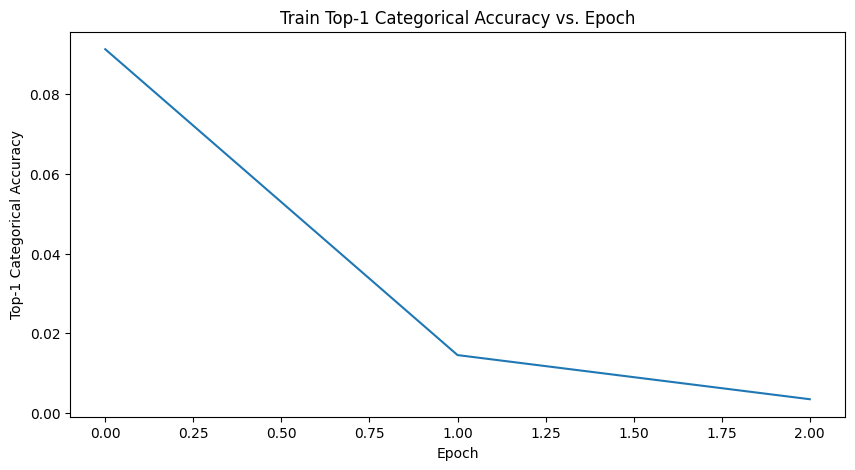

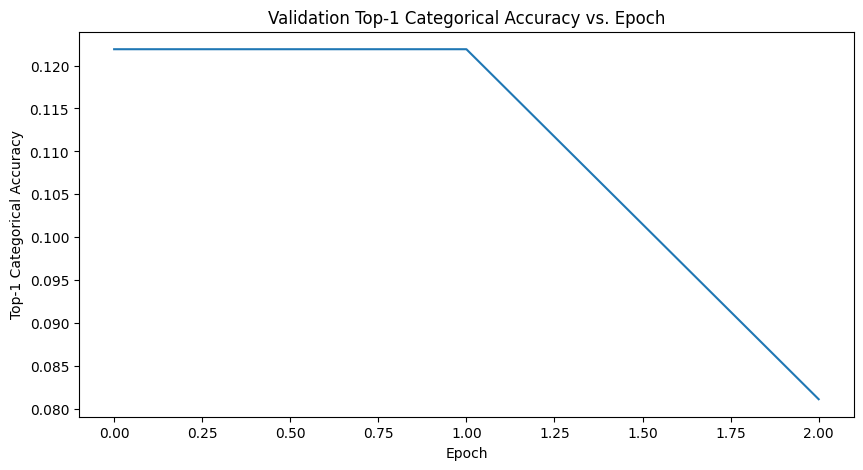

In [22]:
# Plot
import matplotlib.pyplot as plt
nrows = 1
ncols = 2
fig = plt.figure(figsize=(10, 5))

plt.figure(figsize=(10, 5))
plt.plot(history.history['factorized_top_k/top_1_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Top-1 Categorical Accuracy')
plt.title('Train Top-1 Categorical Accuracy vs. Epoch')
plt.show()

# Plot validation factorized_top_k/top_1_categorical_accuracy vs epoch
plt.figure(figsize=(10, 5))
plt.plot(history.history['val_factorized_top_k/top_1_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Top-1 Categorical Accuracy')
plt.title('Validation Top-1 Categorical Accuracy vs. Epoch')
plt.show()

In [23]:
%tensorboard --logdir logs/fit

UsageError: Line magic function `%tensorboard` not found.
